
# Group Project
**Topic:** Categorical & Numerical Data Analysis (Sessions 7–10)  

### How to use this notebook
- **Read the instructions** at the top of each section.  
- Complete all cells labeled **TODO**. If a cell raises `NotImplementedError`, replace the stub with your code.  
- **Do not change filenames** of required outputs; the autograder depends on them.

### Grading breakdown (100 pts)
1. Team Info & Professionalism (names, roles, tidy notebook) — **5 pts**  
2. Load Data (correct dataset path & preview) — **5 pts**  
3. Cleaning (make columns usable, types, missing handling) — **10 pts**  
4. Column Typing & Ordinal setup — **5 pts**  
5. Countplot (sorted) — **8 pts**  
6. Countplot with `hue` — **8 pts**  
7. Bar of means (+ SD error bars) — **10 pts**  
8. Boxplot *or* Violin — **8 pts**  
9. Crosstab stacked counts — **8 pts**  
10. Crosstab row-normalized + % labels — **10 pts**  
11. Heatmap of row proportions — **8 pts**  
12. Facet grid (row/col) — **8 pts**  
13. Executive Summary (6–10 bullets, JSON) — **5 pts**  
14. Project Log (roles, process) — **2 pts**

**Datasets allowed:** `telecom_churn.csv`


## 0) Setup (provided) — *Read-only*

In [31]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, os, json
sns.set_theme(style="whitegrid", palette="muted", context="talk")
plt.rcParams["figure.figsize"] = (8,4)
pd.set_option("display.max_columns", None)
print("Libraries ready ✔")

Libraries ready ✔


## 1) Team Info — **5 pts**

In [32]:
# TODO: Fill your group information (all fields required)
GROUP_NAME = "Group 4"
MEMBERS = ["Brandon Chau","Bryan Tieu","Payton C"]  # 3 names
PRIMARY_DATASET = "telecom_churn.csv"  # or "customer_purchases.csv" | "customer_feedback.csv"
ROLES = {
    "Data Lead": "Brandon",
    "Viz Lead": "Bryan",
    "Writer": "Payton",
    "Integrator": "Bryan"
}
print(GROUP_NAME, MEMBERS, PRIMARY_DATASET, ROLES)

Group 4 ['Brandon Chau', 'Bryan Tieu', 'Payton C'] telecom_churn.csv {'Data Lead': 'Brandon', 'Viz Lead': 'Bryan', 'Writer': 'Payton', 'Integrator': 'Bryan'}


## 2) Load Data — **5 pts**

In [33]:
# TODO: Load "telecom_churn.csv" dataset and show head(), shape, dtypes
# Example:
df = pd.read_csv("./contents/telecom_churn.csv")
print(df.head())
print(df.shape)
print(df.dtypes)

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   


## 3) Cleaning — **10 pts**
**Goal:** Make columns usable. Typical steps (customize to your dataset):  
- Strip spaces from column names  
- Coerce numerics (e.g., `TotalCharges`)  
- Cast binary flags to categories (e.g., `SeniorCitizen` → Yes/No)  
- Drop rows with missing values in key numeric columns (e.g., `MonthlyCharges`, `tenure`)


In [34]:
# TODO: Write your cleaning steps here (modify as needed for your dataset)
# Hints:

# dataset is already cleaned up after 1 run. shouldn't run multiple times
'''
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["SeniorCitizen"] = df["SeniorCitizen"].map({0:"No",1:"Yes"}).astype("category")
df = df[df["MonthlyCharges"].notna()]

print(df.isna().sum())
print(df["International plan"].isna().sum())
print(df["Voice mail plan"].isna().sum())
print(df["Churn"].isna().sum())
'''

'\ndf.columns = [c.strip().replace(" ", "_") for c in df.columns]\ndf["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")\ndf["SeniorCitizen"] = df["SeniorCitizen"].map({0:"No",1:"Yes"}).astype("category")\ndf = df[df["MonthlyCharges"].notna()]\n\nprint(df.isna().sum())\nprint(df["International plan"].isna().sum())\nprint(df["Voice mail plan"].isna().sum())\nprint(df["Churn"].isna().sum())\n'

## 4) Column Typing & (Optional) Ordinal — **5 pts**

In [35]:
# TODO: Identify categorical and numeric columns; optionally set an ordinal category order,
# cat_cols = ...
# num_cols = ...
# Example ordinal:
# df["Contract"] = pd.Categorical(...)

df.columns
cat_cols = [
    "Area code"
    "Voice mail plan",
    "International plan",
    "CHURN",
    "Customer service calls"
]

num_cols = [
    "Account length",
    "Number vmail messages",
    "Total day minutes",
    "Total day calls",
    "Total day charge",
    "Total eve minutes",
    "Total eve calls",
    "Total eve charge",
    "Total night minutes",
    "Total night calls",
    "Total night charge",
    "Total intl minutes",
    "Total intl calls",
    "Total intl charge",
]

## 5) Countplot (sorted) — **8 pts** → saves `fig_countplot.png`

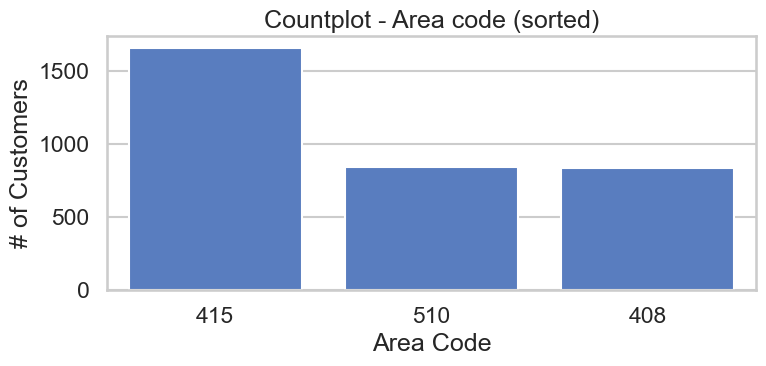

In [36]:
# TODO: Pick a categorical column with 3–8 levels, sort by frequency, plot using countplot, label & save
# cat = ...
# order = ...
# ax = ...
# plt.title(f"Countplot — {cat} (sorted)"); plt.xticks(rotation=20); plt.tight_layout()
# ax.figure.savefig("fig_countplot.png", dpi=220); plt.show()

cat = "Area code"
order = df[cat].value_counts(ascending=False).index
ax = sns.countplot(data = df, order = order, x = cat)
plt.xlabel("Area Code")
plt.ylabel("# of Customers")
plt.title(f"Countplot - {cat} (sorted)")
plt.tight_layout()
ax.figure.savefig("fig_countplot.png", dpi=220)
plt.show()

## 6) Countplot with `hue` — **8 pts** → saves `fig_countplot_hue.png`

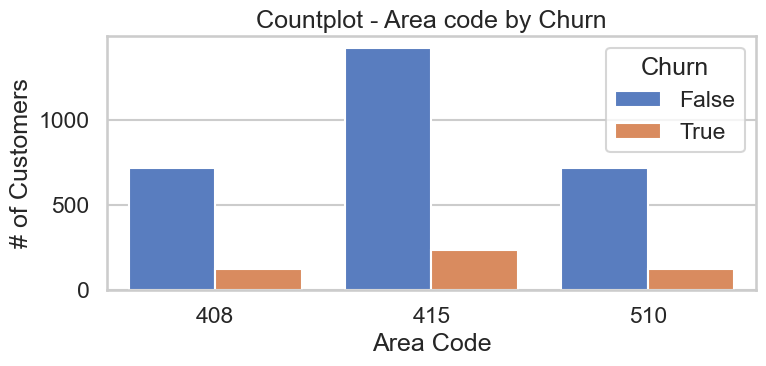

In [37]:
# TODO: Add a second categorical as hue still using countplot
# hue = ...
# ax = ...
# plt.title(f"Countplot — {cat} by {hue}"); plt.xticks(rotation=20);
# plt.tight_layout()
# ax.figure.savefig("fig_countplot_hue.png", dpi=220);
# plt.show()


hue = "Churn"
ax = sns.countplot(data = df, x = cat, hue = hue)
plt.xlabel("Area Code")
plt.ylabel("# of Customers")
plt.title(f"Countplot - {cat} by {hue}")
plt.tight_layout()
ax.figure.savefig("fig_countplot_hue.png", dpi=220)
plt.show()


## 7) Bar of Means (+ SD) — **10 pts** → saves `fig_bar_means.png`

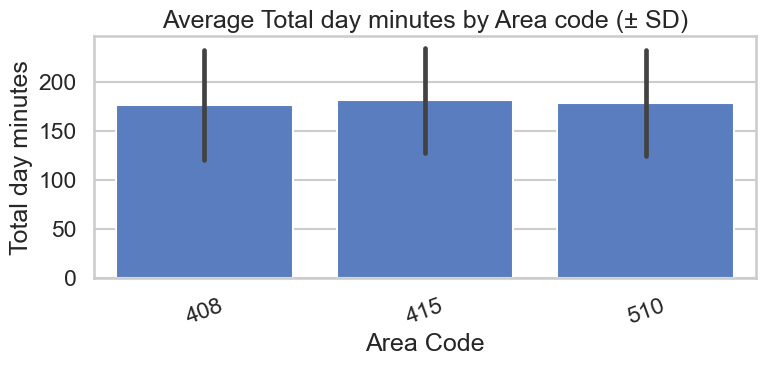

In [38]:
# TODO: Choose a numeric col; show mean ± SD by category, plot a bar plot, and save
num = "Total day minutes"
ax = sns.barplot(data = df, x = cat, y = num, errorbar="sd")
plt.xlabel("Area Code")
plt.title(f"Average {num} by {cat} (± SD)")
plt.xticks(rotation=20)
plt.tight_layout()
ax.figure.savefig("fig_bar_means.png", dpi=220)
plt.show()

## 8) Boxplot *or* Violin — **8 pts** → saves `fig_box_or_violin.png`

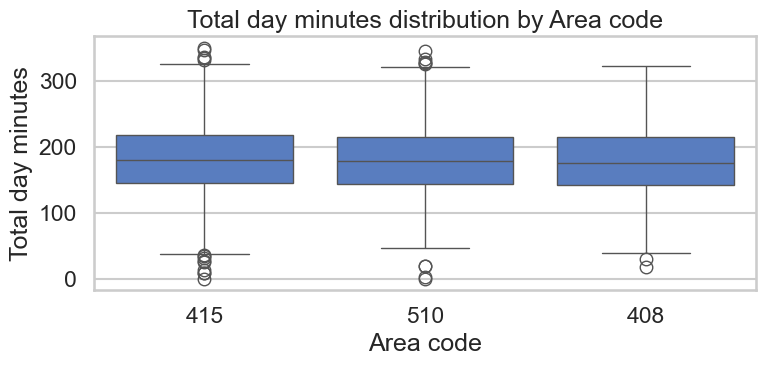

In [49]:
# TODO: Visualize distribution of numeric by category (box or violin)
ax = sns.boxplot(data = df, x = cat, y = num, order = order)
plt.title(f"{num} distribution by {cat}"); plt.xlabel(cat); plt.ylabel(num)
plt.tight_layout()
plt.show()
ax.figure.savefig("fig_box_or_violin.png", dpi=220)


## 9) Crosstab Stacked Counts — **8 pts** → saves `fig_crosstab_stacked_counts.png`

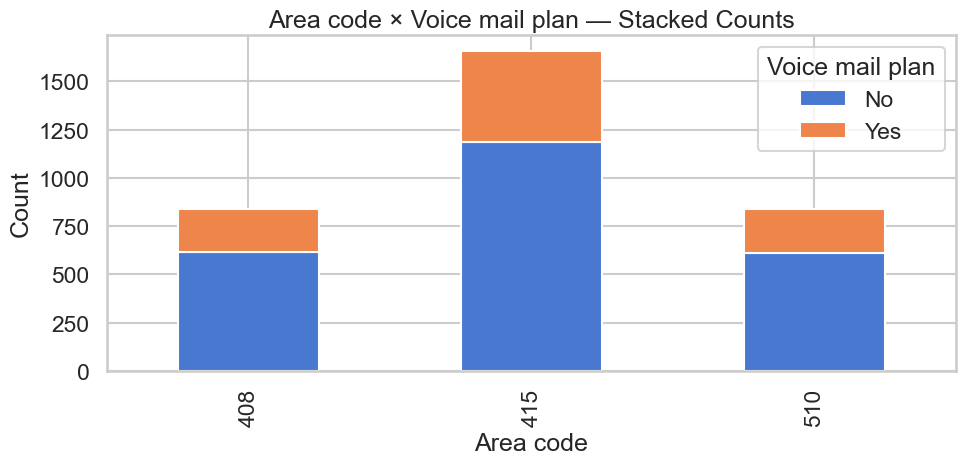

In [40]:
# TODO: Pick a second categorical (cat2); build crosstab; stacked bar counts
# cat2 = ...
# ct = ...
# ax = ...


cat2 = "Voice mail plan"
ct = pd.crosstab(df[cat], df[cat2])
ax = ct.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title(f"{cat} × {cat2} — Stacked Counts"); plt.ylabel("Count"); plt.xlabel(cat);
plt.tight_layout()
plt.savefig("fig_crosstab_stacked_counts.png", dpi=220); plt.show()

## 10) Crosstab Row-Normalized + % Labels — **10 pts** → saves `fig_crosstab_stacked_props.png`

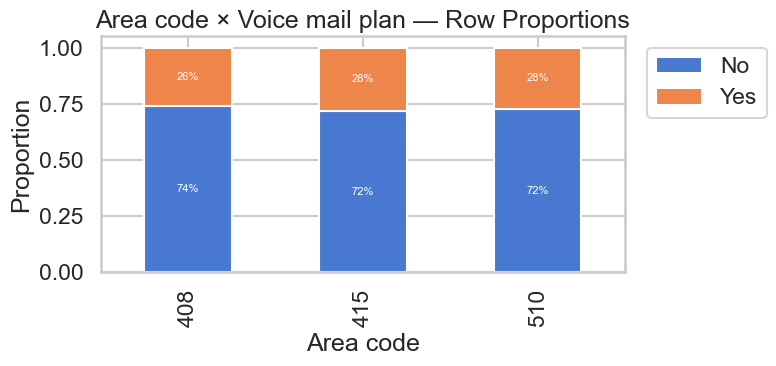

In [41]:
# TODO: Normalize rows to proportions; add % labels to larger segments
ct_prop = ct.div(ct.sum(axis=1), axis=0)
ax = ct_prop.plot(kind = "bar", stacked = True)
for container in ax.containers:
    vals = container.datavalues
    labels = [f"{v*100:.0f}%" if v>=0.08 else "" for v in vals]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white")
plt.title(f"{cat} × {cat2} — Row Proportions")
plt.ylabel("Proportion")
plt.xlabel(cat)
plt.legend(bbox_to_anchor=(1.02, 1), loc="best")
plt.tight_layout()
plt.savefig("fig_crosstab_stacked_props.png", dpi=220)
plt.show()


## 11) Heatmap of Row Proportions — **8 pts** → saves `fig_heatmap_props.png`

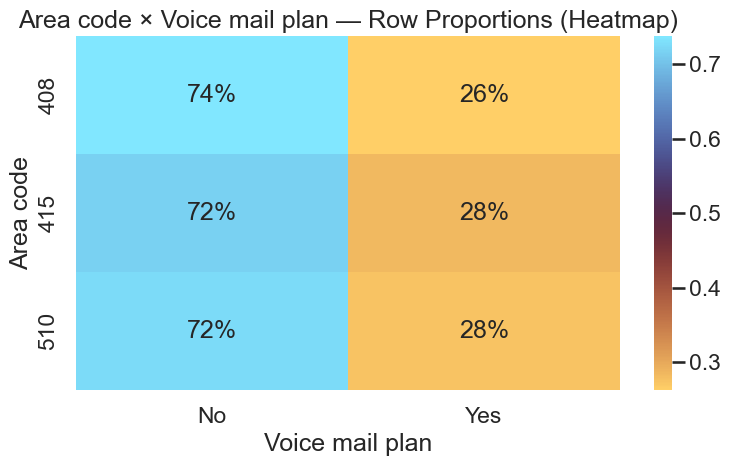

In [42]:
# TODO: Heatmap of ct_prop (annotated as percentages)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5));
sns.heatmap(ct_prop, annot=True, fmt=".0%", cbar=True, cmap="managua")
plt.title(f"{cat} × {cat2} — Row Proportions (Heatmap)");
plt.xlabel(cat2);
plt.ylabel(cat);
plt.tight_layout()
plt.savefig("fig_heatmap_props.png", dpi=220);
plt.show()


## 12) Facet Grid — **8 pts** → saves `fig_facet_grid.png`

/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_9957/1319026182.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


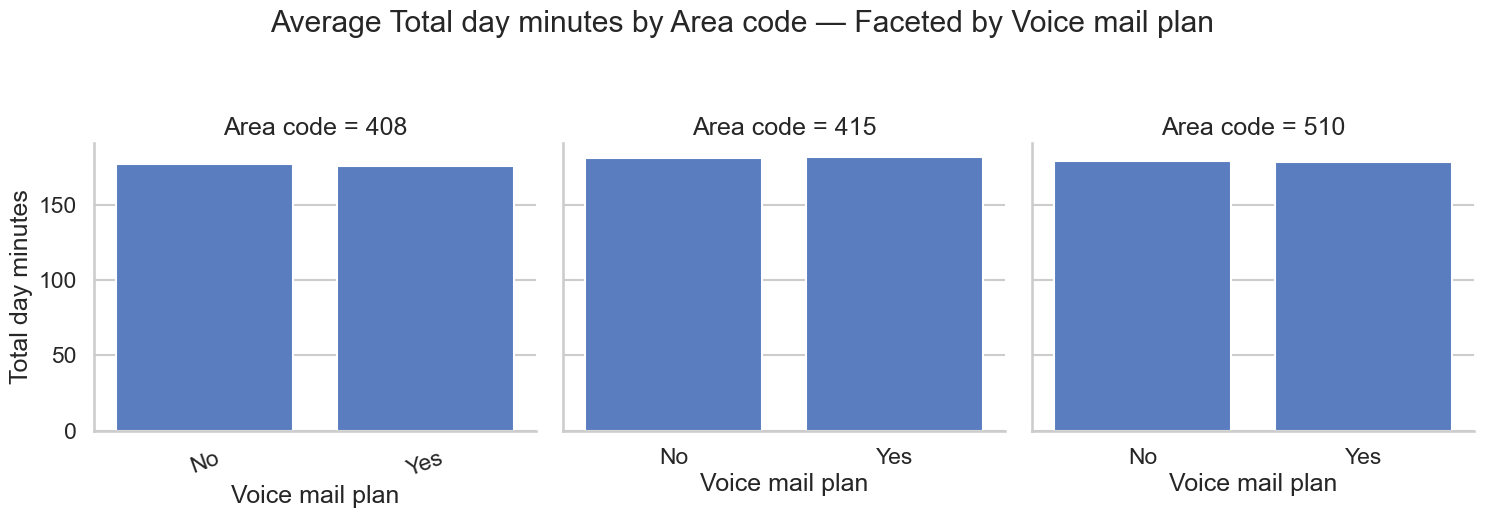

/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_9957/1319026182.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


<Figure size 800x400 with 0 Axes>

/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_9957/1319026182.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)


<Figure size 800x400 with 0 Axes>

In [47]:
# TODO: Facet by a categorical (e.g., col=cat2) for mean of numeric by cat
gdf = df.groupby([cat, cat2], as_index=False)[num].mean()
g = sns.catplot(data = gdf, x=cat2, y=num, col=cat, kind="bar")
for ax in g.axes.flat:
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
  g.fig.suptitle(f"Average {num} by {cat} — Faceted by {cat2}", y=1.05)
  g.savefig("fig_facet_grid.png", dpi=220)  # type: ignore
  plt.tight_layout()
  plt.show()


## 13) Executive Summary (JSON) — **5 pts** → saves `summary_answers.json`

In [44]:
# TODO: Replace bullets with 6–10 one-sentence findings
import json

summary = {
    "dataset": "telecom_churn.csv",
    "top_takeaways": [
        "Bullet 1: From out data we can gather that area code first has more customers that the other area codes.",
        "Bullet 2: Even though area code 415 has a greater number of customers, the ratio of the churned vs non churned customers stays roughly the same across the area codes.: ",
        "Bullet 3: Then across all the regions given, there looks to be a low adoption rate no matter the region.",
        "Bullet 4: Even with the low adoption rates, there is a consistency to them no matter their size ranging from 26-28%.",
        "Bullet 5: The total minutes used in a day was consistent as well with the average being around 180 minutes in every region.",
        "Bullet 6: The plots indicate that the medians for each region are identical with times, but the spread of usage is wide with the high being almost 150 and the low being almost 0."
    ]
}
with open("summary_answers.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved summary_answers.json")

Saved summary_answers.json


## 14) Project Log (Markdown) — **2 pts** → saves `project_log.md`

In [45]:
# TODO: Write 5–10 bullets describing roles, work split, challenges, next steps
log_md = '''# Project Log
- Roles: Data Lead (Brandon), Viz Lead (Bryan), Writer (Payton), Integrator (Bryan)
- What went well:
  - Identifying tasks and what needed to be done came first.
  - Following that part, reading directions and understanding what needed to be done we were able to split the work.
  - Once the work was split based on what seemed appropriate we were able to get everything done.
- Challenges:
  - Initial challenges were splitting up work load and choosing who should be doing what.
  - Not every tile had the same amount of work dedicated for it so there was discussion on what each person should be given for their part of work.
- Next steps / recommendations:
  - Next steps from when the work was assigned was what could be done within the day and what may need to be done in the future.
'''
with open("project_log.md", "w") as f:
    f.write(log_md)
print("Initialized project_log.md — open it in the Files pane and edit.")

Initialized project_log.md — open it in the Files pane and edit.


## 15) 🔎 Autograder (presence/size only) — *Run before submitting*

In [46]:
required = [
    "fig_countplot.png","fig_countplot_hue.png","fig_bar_means.png","fig_box_or_violin.png",
    "fig_crosstab_stacked_counts.png","fig_crosstab_stacked_props.png","fig_heatmap_props.png",
    "fig_facet_grid.png","summary_answers.json","project_log.md",
]
report = {}
for path in required:
    ok = os.path.exists(path) and os.path.getsize(path) > 500  # >=500 bytes
    report[path] = "OK" if ok else "MISSING/SMALL"
print("Autograder report:")
for k,v in report.items():
    print(f" - {k}: {v}")
print("\nPASS" if all(v=='OK' for v in report.values()) else "\nNeeds attention (see items above).")

Autograder report:
 - fig_countplot.png: OK
 - fig_countplot_hue.png: OK
 - fig_bar_means.png: OK
 - fig_box_or_violin.png: OK
 - fig_crosstab_stacked_counts.png: OK
 - fig_crosstab_stacked_props.png: OK
 - fig_heatmap_props.png: OK
 - fig_facet_grid.png: OK
 - summary_answers.json: OK
 - project_log.md: OK

PASS
